# Log-probability descriptive analysis (isolated-judgment protocol)

Cross-checks `statistical_analysis/logprob_analysis.py` (a dependency-free, pure-stdlib
version run locally, without scipy/pandas/matplotlib available) using pandas/scipy/matplotlib
on the server. The two should produce identical `spearman_rho` and summary-stat values —
if they don't, that's a bug worth chasing down rather than trusting either blindly.

Covers the 4 models that currently have logprob data: Gemma-12B, Gemma-E4B, Qwen3-VL-4B,
Qwen3-VL-8B. Pixtral-12B and Mistral Small 3.1 24B are on hold pending the roster-exclusion
decision (see `docs/SESSION_HANDOFF.md`) — this notebook will pick them up automatically
(no code change needed) once/if their logprob files exist, since missing files are skipped.

Stays at the **descriptive layer only** by explicit decision (2026-08-03) — no significance
tests or corrections beyond the p-values `scipy.stats.spearmanr` returns for free. If a
formal confirmatory test is needed later, follow the pattern already used in
`gee_analysis.ipynb` (paired sign test) once there's a specific hypothesis to confirm rather
than explore.


1. How we got the log-prob results: instead of just reading the model's printed word ("like" or "scroll"), we captured the model's raw probability distribution over its very first generated token and converted that into a normalized probability of "like" (or "yes") between just the possible candidate answers — giving us the model's real internal confidence even in trials where the printed word never changes.

2. How the descriptive scan flagged which combinations stood out: a model/condition/phrasing combination was flagged as "worth a directed test" specifically when its decoded answer was saturated (stuck at ≥99% or ≤1% "like," so it looks completely uninformative on the surface) but the underlying probabilities still had real spread (standard deviation above 0.05) — that combination of "flat printed answer + spread-out hidden confidence" is what pointed us to Gemma-12B and Qwen3-VL-4B as the cases with a real hidden signal worth confirming.

## 0-1: Setup

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display

ROOT_DIR = Path().resolve().parents[0]  # statistical_analysis/ -> repo root


In [2]:
# Confirmed six-model roster. Both Ministral entries added 2026-08-23: this notebook had been
# left on the pre-Ministral four-model roster, so every CSV it wrote -- and every log-probability
# figure in the thesis -- was a four-model result reported on a six-model one.
MODELS = {
    "gemma-12b":       ROOT_DIR / "experiments/e1/gemma4-12b/outputs",
    "gemma-e4b":       ROOT_DIR / "experiments/e1/gemma4-e4b/outputs",
    "qwen3-vl-4b":     ROOT_DIR / "experiments/e1/qwen3-vl-4b/outputs",
    "qwen3-vl-8b":     ROOT_DIR / "experiments/e1/qwen3-vl-8b/outputs",
    "ministral-3-8b":  ROOT_DIR / "experiments/e1/ministral-3-8b/outputs",
    "ministral-3-14b": ROOT_DIR / "experiments/e1/ministral-3-14b/outputs",
    # Pixtral-12B and Mistral Small 3.1 24B are appendix-only (Appendix E) and have no
    # log-probability data at all -- deliberately absent, not pending.
}

# `likes_only` dropped 2026-08-23: superseded by likes_only_noise, cited nowhere in the thesis,
# and its raw files no longer exist for Ministral-3-14B, so keeping it would break the six-model
# run for a figure nothing uses.
CONDITIONS = {
    "baseline":         {"single": "e1_results_baseline_logprobs.json",         "yesno": "e1_results_baseline_yesno_logprobs.json"},
    "metrics":          {"single": "e1_results_metrics_logprobs.json",          "yesno": "e1_results_metrics_yesno_logprobs.json"},
    "likes_only_noise": {"single": "e1_results_likes_only_noise_logprobs.json", "yesno": "e1_results_likes_only_noise_yesno_logprobs.json"},
}
WORD = {"single": "like", "yesno": "yes"}


## 2: Load & consolidate

One row per trial, tagged with `model`/`condition`/`phrasing`. `p_like` is the
forced-choice softmax probability the model assigned to "like"/"yes" (see
`experiments/e1/e1_utils/logprob_scoring.py::extract_candidate_logprobs`), read directly
off the first generated token's distribution — not the greedy-decoded answer.

In [3]:
def load_logprob_file(path, like_word):
    records = json.loads(path.read_text())
    rows = []
    for r in records:
        rows.append({
            "image": r["image"], "variant": r["variant"],
            "scale_value": r.get("scale_value"),
            "decoded_answer": r["answer"],
            "p_like": r["candidates"][like_word]["prob_forced_choice"],
        })
    return pd.DataFrame(rows)

frames = []
for model, outdir in MODELS.items():
    for condition, files in CONDITIONS.items():
        for phrasing, like_word in WORD.items():
            fpath = outdir / files[phrasing]
            if not fpath.exists():
                continue
            df = load_logprob_file(fpath, like_word)
            df["model"], df["condition"], df["phrasing"] = model, condition, phrasing
            frames.append(df)

combined = pd.concat(frames, ignore_index=True)
combined["decoded_like_binary"] = combined["decoded_answer"].isin(["like", "yes"]).astype(int)
print(f"Loaded {len(combined)} total trials.")

out_dir = ROOT_DIR / "statistical_analysis/outputs"
out_dir.mkdir(parents=True, exist_ok=True)
combined.to_csv(out_dir / "logprob_combined.csv", index=False)


Loaded 30400 total trials.


## Section 2 — Saturation check

Is the decoded protocol's 0%/100% saturation genuine, or is it hiding real gradation
underneath? A saturated cell (`decoded_rate_pct` near 0 or 100) with a large `std_p_like`
means the binary decode was masking real variation — the model wasn't uniformly certain,
it just always landed on the same side of the threshold.

In [4]:
summary = combined.groupby(["model", "condition", "phrasing"]).agg(
    n=("p_like", "size"),
    decoded_rate_pct=("decoded_like_binary", lambda s: round(s.mean() * 100, 1)),
    mean_p_like=("p_like", lambda s: round(s.mean(), 4)),
    std_p_like=("p_like", lambda s: round(s.std(), 4)),
    pct_confident=("p_like", lambda s: round(((s < 0.01) | (s > 0.99)).mean() * 100, 1)),
).reset_index()
display(summary)

summary.to_csv(out_dir / "logprob_saturation_summary.csv", index=False)


,model,condition,phrasing,n,decoded_rate_pct,mean_p_like,std_p_like,pct_confident
0,gemma-12b,baseline,single,200,0.0,0.0002,0.0001,100.0
1,gemma-12b,baseline,yesno,200,0.0,0.0000,0.0000,100.0
2,gemma-12b,likes_only,single,1200,0.0,0.0004,0.0002,100.0
3,gemma-12b,likes_only,yesno,1200,0.0,0.0001,0.0001,100.0
4,gemma-12b,likes_only_noise,single,1200,0.0,0.0004,0.0002,100.0
5,gemma-12b,likes_only_noise,yesno,1200,0.0,0.0001,0.0001,100.0
6,gemma-12b,metrics,single,1200,0.0,0.0003,0.0002,100.0
7,gemma-12b,metrics,yesno,1200,0.0,0.0001,0.0001,100.0
8,gemma-e4b,baseline,single,200,96.0,0.9942,0.0457,95.5
9,gemma-e4b,baseline,yesno,200,0.0,0.0000,0.0000,100.0


In [5]:
flagged = summary[((summary.decoded_rate_pct >= 99) | (summary.decoded_rate_pct <= 1)) & (summary.std_p_like > 0.05)]
print("Saturated-but-not-really cells (decoded flat, std_p_like > 0.05):")
display(flagged)


Saturated-but-not-really cells (decoded flat, std_p_like > 0.05):


,model,condition,phrasing,n,decoded_rate_pct,mean_p_like,std_p_like,pct_confident
16,qwen3-vl-4b,baseline,single,200,100.0,0.9173,0.0798,3.5


## Section 3 — Does confidence track engagement disparity where decode doesn't move?

Spearman correlation between `scale_value` and `p_like`, computed separately per
model/condition/phrasing/variant. A model whose decoded answer never changes across scale
values can still show a real (positive or negative) `spearman_rho` here — that would mean
it's sensitive to engagement disparity internally even though that sensitivity never
crosses the threshold needed to flip its decision.

`p_value` is included since `scipy` returns it for free, but per the descriptive-layer
decision this isn't being used for any significance claim or correction here.

In [6]:
scaled = combined[combined["scale_value"].notna()]
rows = []
for (model, condition, phrasing, variant), g in scaled.groupby(["model", "condition", "phrasing", "variant"]):
    if g["scale_value"].nunique() > 1:
        rho, p = spearmanr(g["scale_value"], g["p_like"])
        rows.append({"model": model, "condition": condition, "phrasing": phrasing,
                      "variant": variant, "n": len(g), "spearman_rho": round(rho, 3), "p_value": p})
corr_df = pd.DataFrame(rows)
display(corr_df)

corr_df.to_csv(out_dir / "logprob_scale_correlation.csv", index=False)


,model,condition,phrasing,variant,n,spearman_rho,p_value
0,gemma-12b,likes_only,single,correct,600,0.421,3.494393e-27
1,gemma-12b,likes_only,single,incorrect,600,0.134,9.845195e-04
2,gemma-12b,likes_only,yesno,correct,600,0.434,6.825299e-29
3,gemma-12b,likes_only,yesno,incorrect,600,0.134,1.010574e-03
4,gemma-12b,likes_only_noise,single,correct,600,0.333,5.211949e-17
5,gemma-12b,likes_only_noise,single,incorrect,600,0.108,7.982336e-03
6,gemma-12b,likes_only_noise,yesno,correct,600,0.341,8.726831e-18
7,gemma-12b,likes_only_noise,yesno,incorrect,600,0.116,4.397567e-03
8,gemma-12b,metrics,single,correct,600,0.184,5.540663e-06
9,gemma-12b,metrics,single,incorrect,600,0.004,9.225330e-01


## Section 4 — Correctness-sensitivity gap: logprob-based vs. decoded-answer-based

`logprob_gap` = mean `p_like` for `correct`-variant images minus `incorrect`-variant
images. `decoded_gap_pct` is the same comparison using the binary decoded answer, in
percentage points, so the two columns are on different scales (probability vs. percentage
points) — compare them by direction and relative size, not raw magnitude.

In [7]:
gap = combined.groupby(["model", "condition", "phrasing", "variant"])[["p_like", "decoded_like_binary"]].mean().unstack("variant")
gap["logprob_gap"] = gap[("p_like", "correct")] - gap[("p_like", "incorrect")]
gap["decoded_gap_pct"] = (gap[("decoded_like_binary", "correct")] - gap[("decoded_like_binary", "incorrect")]) * 100
gap_display = gap[["logprob_gap", "decoded_gap_pct"]].reset_index()
display(gap_display)

gap_display.to_csv(out_dir / "logprob_correctness_gap.csv", index=False)


,model,condition,phrasing,logprob_gap,decoded_gap_pct
variant,,,,,
0,gemma-12b,baseline,single,-0.000159,0.000000
1,gemma-12b,baseline,yesno,-0.000052,0.000000
2,gemma-12b,likes_only,single,-0.000051,0.000000
3,gemma-12b,likes_only,yesno,-0.000066,0.000000
4,gemma-12b,likes_only_noise,single,-0.000063,0.000000
5,gemma-12b,likes_only_noise,yesno,-0.000063,0.000000
6,gemma-12b,metrics,single,-0.000124,0.000000
7,gemma-12b,metrics,yesno,-0.000063,0.000000
8,gemma-e4b,baseline,single,-0.005977,4.000000


## Section 5 — Distribution plots

Worth plotting first, per the local descriptive run (2026-08-03): Qwen3-VL-4B's `baseline`
condition decodes 100% "like" but is far from uniformly confident underneath: only ~3.5%
of trials are actually >0.99 or <0.01. Gemma-12B's `likes_only` condition never once
decodes to "like" (0% at every scale value), but still shows a real positive
`scale_value`-vs-`p_like` correlation for `correct`-variant images (ρ≈0.42 in the local
run) — the plot below should show that as a rightward density shift with scale, even
though every single trial still decodes to "scroll".

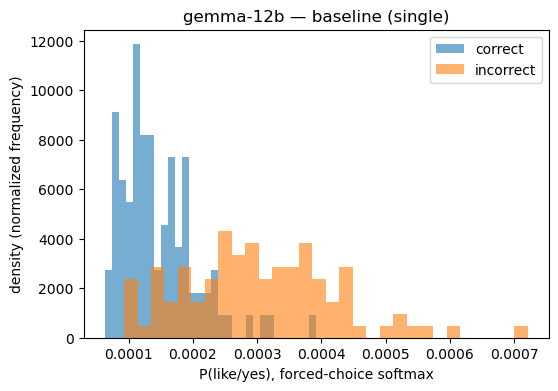

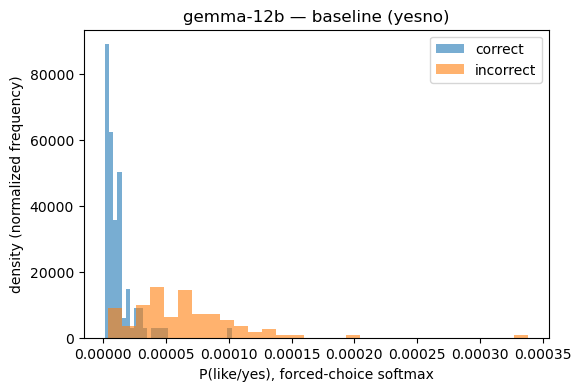

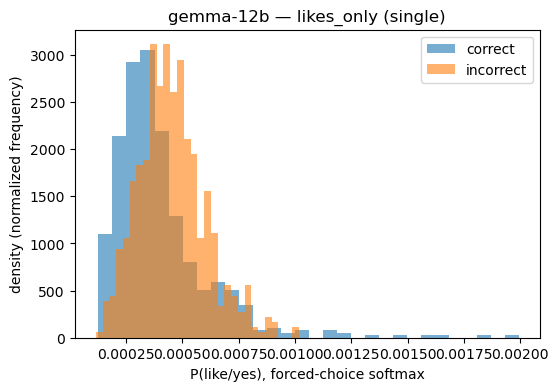

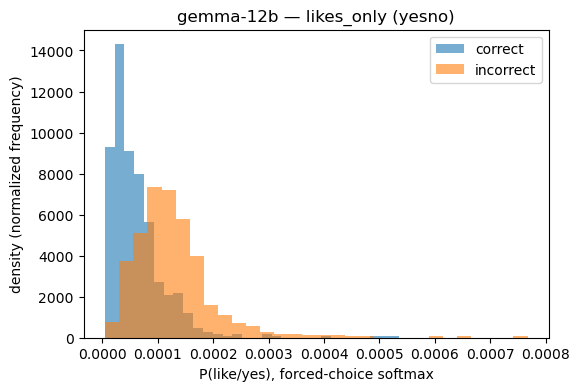

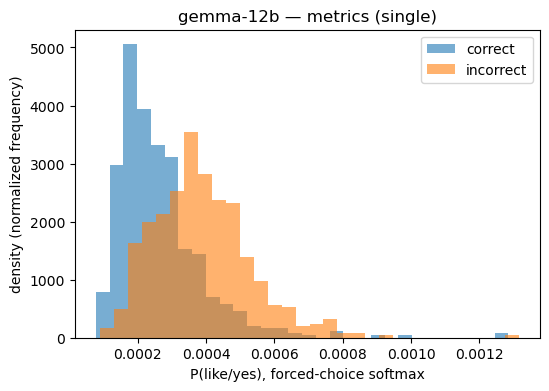

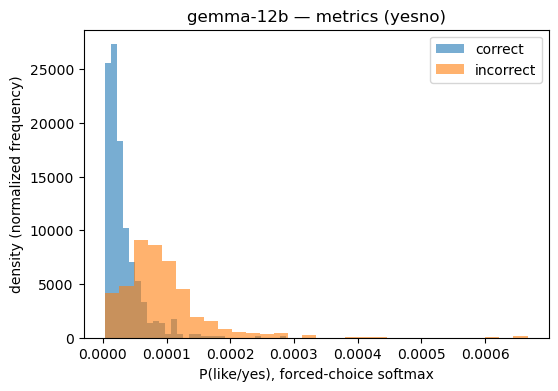

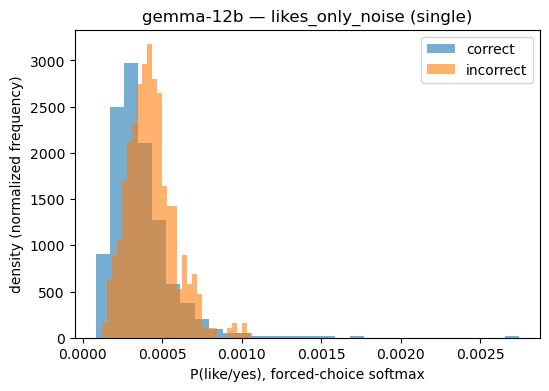

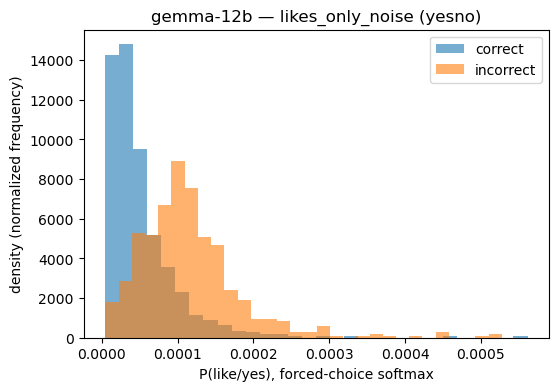

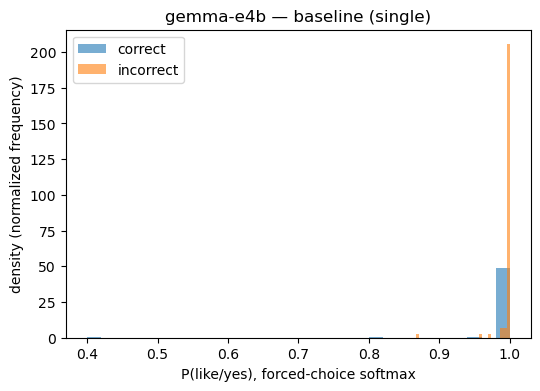

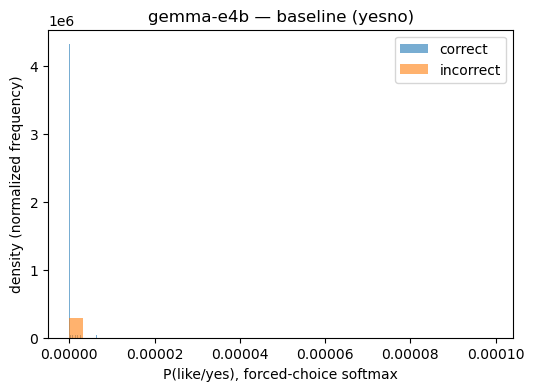

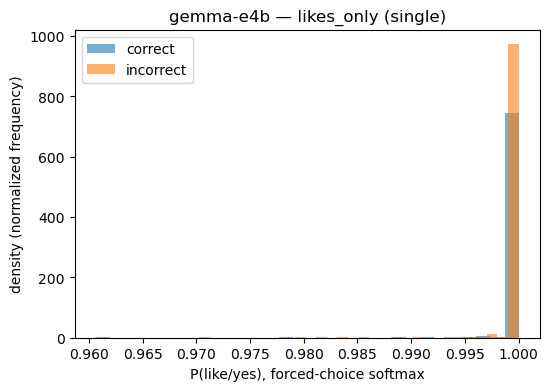

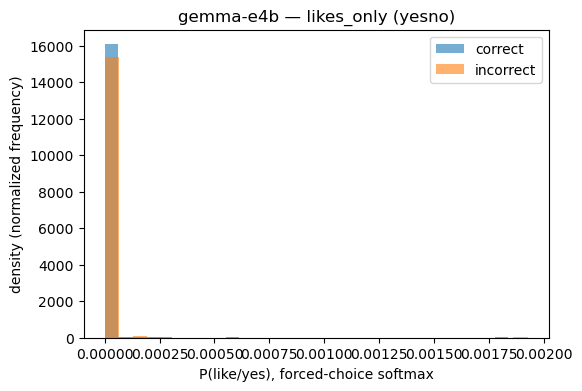

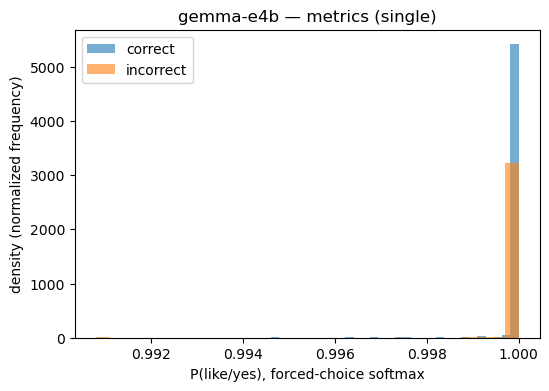

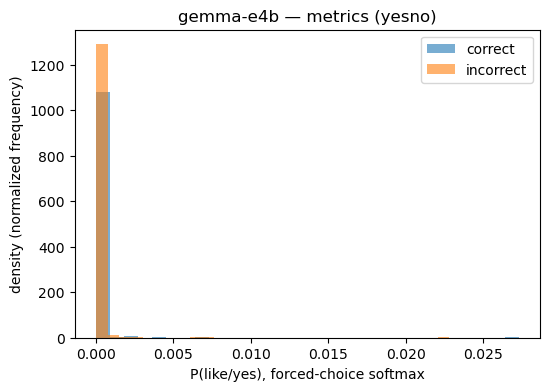

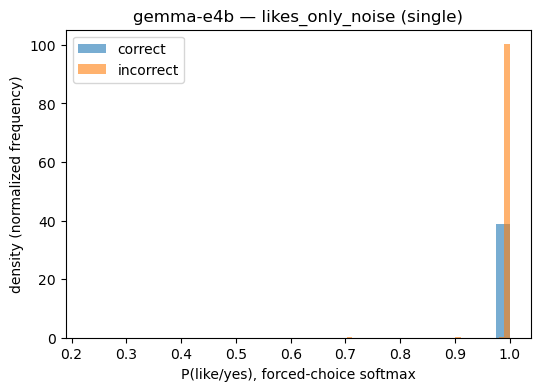

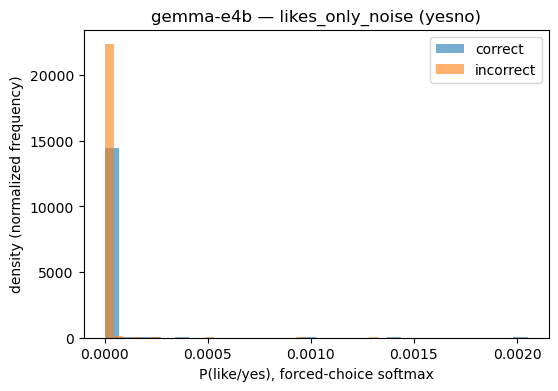

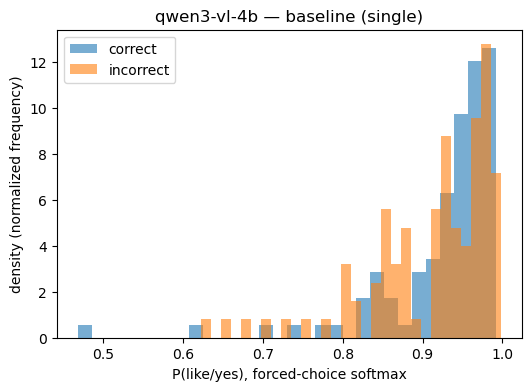

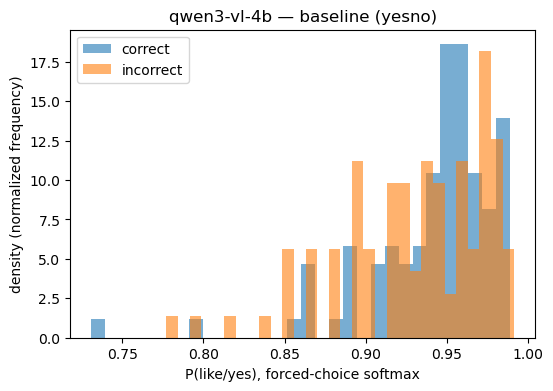

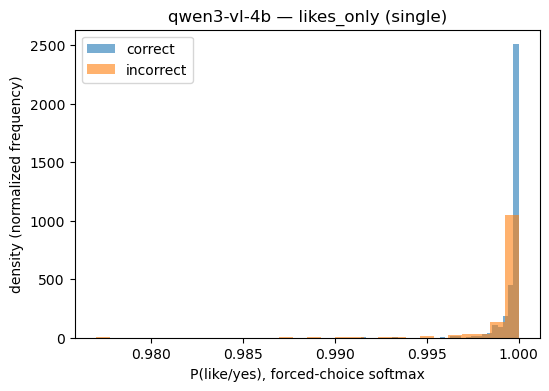

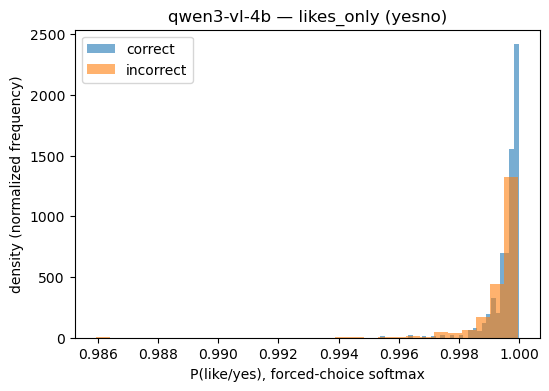

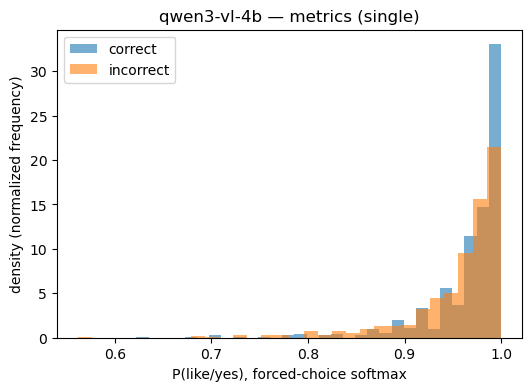

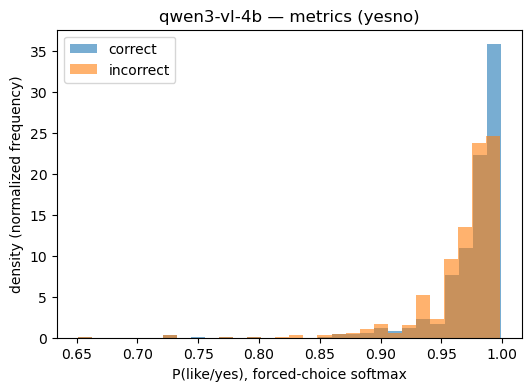

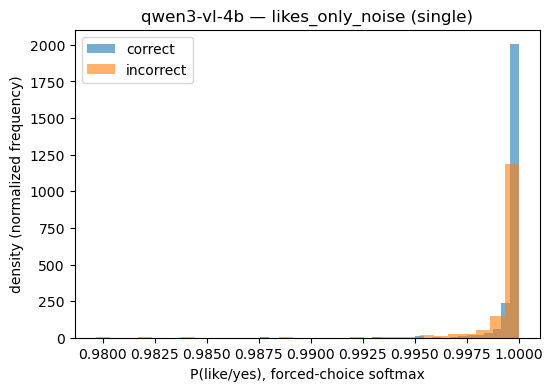

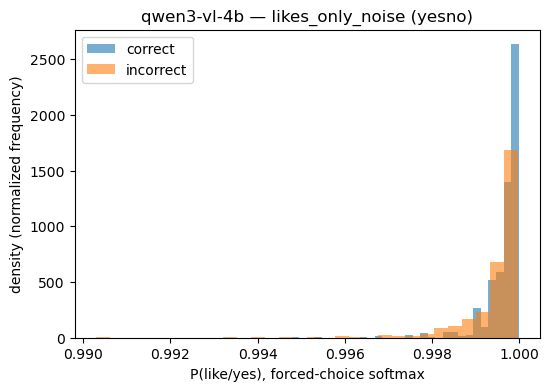

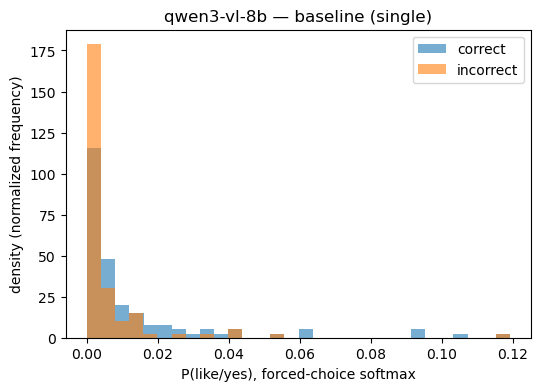

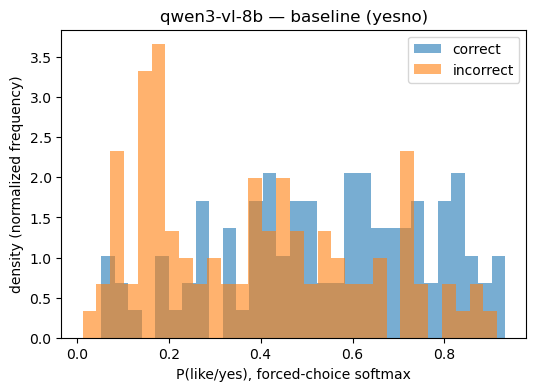

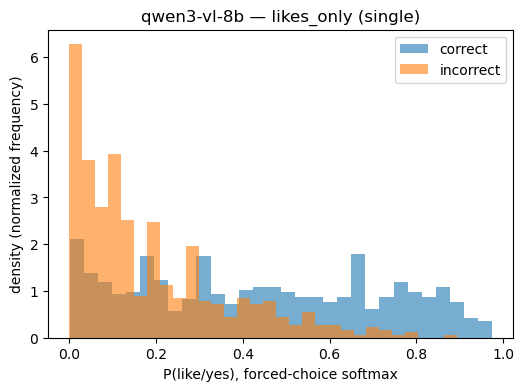

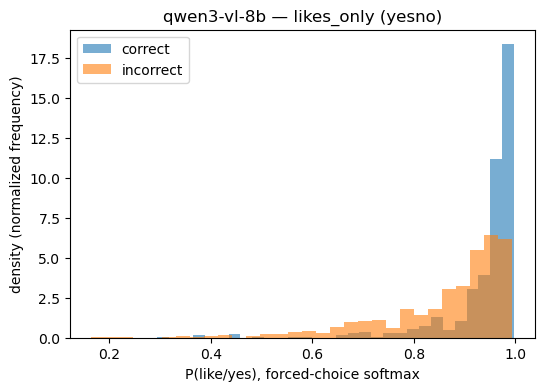

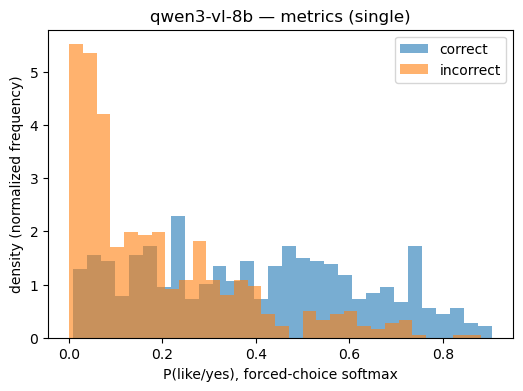

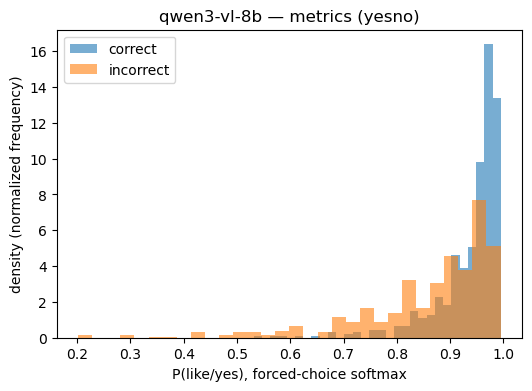

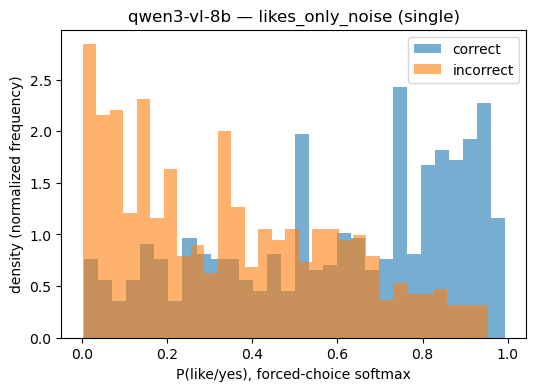

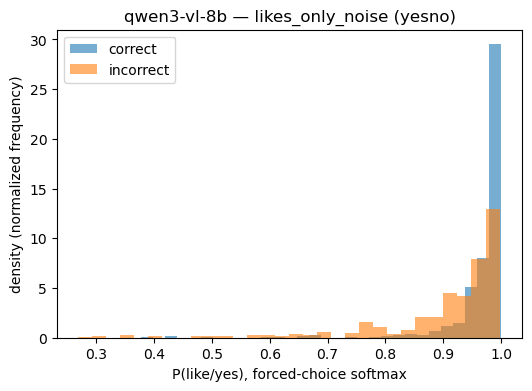

In [8]:
def plot_p_like_distribution(df, model, condition, phrasing):
    sub = df[(df.model == model) & (df.condition == condition) & (df.phrasing == phrasing)]
    if sub.empty:
        return
    fig, ax = plt.subplots(figsize=(6, 4))
    # density=True (normalized frequency) so panels with different n (single=100/scale, paired
    # scale conditions=600) are visually comparable on the same y-axis.
    ax.hist(sub[sub.variant == "correct"]["p_like"], bins=30, alpha=0.6, density=True, label="correct")
    ax.hist(sub[sub.variant == "incorrect"]["p_like"], bins=30, alpha=0.6, density=True, label="incorrect")
    ax.set_xlabel("P(like/yes), forced-choice softmax")
    ax.set_ylabel("density (normalized frequency)")
    ax.set_title(f"{model} — {condition} ({phrasing})")
    ax.legend()
    plt.show()


# 2026-08 (supervisor item 1): plot every model x condition x phrasing combination that has data,
# not just the 2 illustrative examples originally picked out below -- 4 models x 4 conditions x
# 2 phrasings = up to 32 panels.
for _model in combined["model"].unique():
    for _condition in combined["condition"].unique():
        for _phrasing in combined["phrasing"].unique():
            plot_p_like_distribution(combined, _model, _condition, _phrasing)


Qwen3-VL-4B — baseline (single): x-axis runs 0.5–1.0, and the two colors are piled on top of each other near 1.0 — this is the "everything is saturated near 100% like" pattern already established in your thesis (§5.3): the decoded answer is uninformative because the model says "like" almost regardless of content. There's a faint hint of orange skewing slightly lower around 0.8–0.9, consistent with the small, real correctness-sensitivity your directed test already found (63/92 images, p≈5×10⁻⁴) — but visually it's subtle, which matches "real but modest," not a dramatic effect.

In [9]:
# Superseded 2026-08 -- the loop in the cell above now plots every combination.


## Section 6 — Directed confirmatory test (not part of the exploratory scan above)

Section 3 scanned 48 model/condition/phrasing/variant combinations at once — useful for
spotting candidates, but no single p-value from that scan should be cited on its own
(with that many comparisons running at once, a few will look extreme by chance alone).

This section takes the one result that stood out — Gemma-12B, correct-variant images,
ρ≈0.42 in `likes_only` and ρ≈0.33 in `likes_only_noise` (Section 3) — and re-tests it by
itself, with a simpler, more transparent method: an exact sign test, the same
distribution-free approach already used elsewhere in this project (the Gemma-12B vs.
Gemma-E4B diagonal-competence test, `docs/THESIS.md` §6.1).

**Reported on `likes_only_noise`, not `likes_only`** — this project treats
`likes_only_noise` (round engagement numbers replaced with non-round ones, to rule out
round-number anchoring) as the condition that actually gets reported, with `likes_only`
kept only as a replication check (see `docs/SESSION_HANDOFF.md` on this decision).

**The question, in plain terms:** for the same (factually correct) post, does Gemma-12B's
internal "want to like this" probability go up when the displayed engagement number goes
from the smallest tested value (10) to the largest (1,000,000)? Answered once, per image,
with no batch of comparisons involved — so the resulting p-value can be trusted directly.

In [10]:
import math

def sign_test_p(n, k):
    """Exact two-sided sign test p-value (binomial, p=0.5). No scipy needed \u2014
    same method already used for the Gemma-12B vs. Gemma-E4B test in THESIS.md \u00a76.1."""
    if n == 0:
        return 1.0
    k = max(k, n - k)
    tail = sum(math.comb(n, i) for i in range(k, n + 1)) / (2 ** n)
    return min(1.0, 2 * tail)

def directed_scale_test(condition, save_as):
    sub = combined[(combined.model == "gemma-12b") & (combined.condition == condition) &
                   (combined.phrasing == "single") & (combined.variant == "correct")].copy()
    sub["num"] = sub["image"].str.split("_").str[0]

    low = sub[sub.scale_value == 10].set_index("num")["p_like"]
    high = sub[sub.scale_value == 1_000_000].set_index("num")["p_like"]

    paired = pd.DataFrame({"p_like_at_10": low, "p_like_at_1M": high}).dropna()
    paired["went_up"] = paired["p_like_at_1M"] > paired["p_like_at_10"]
    paired["went_down"] = paired["p_like_at_1M"] < paired["p_like_at_10"]

    up = int(paired["went_up"].sum())
    down = int(paired["went_down"].sum())
    n = up + down

    p = sign_test_p(n, up)
    print(f"[{condition}] Images where P(like) increased from 10 to 1,000,000 reactions: {up} / {n} (n excludes ties)")
    print(f"[{condition}] Sign test p-value: {p:.3e}")

    paired.to_csv(out_dir / save_as)
    return paired

# Primary, reported result:
paired_noise = directed_scale_test("likes_only_noise", "logprob_directed_sign_test_gemma12b_likes_only_noise.csv")

# Replication check on likes_only (kept only as a secondary confirmation, not the headline number):
paired_plain = directed_scale_test("likes_only", "logprob_directed_sign_test_gemma12b_likes_only.csv")


[likes_only_noise] Images where P(like) increased from 10 to 1,000,000 reactions: 93 / 99 (n excludes ties)
[likes_only_noise] Sign test p-value: 3.774e-21
[likes_only] Images where P(like) increased from 10 to 1,000,000 reactions: 94 / 100 (n excludes ties)
[likes_only] Sign test p-value: 2.006e-21


## Section 7 — Directed confirmatory test: Qwen3-VL-4B baseline (correct vs. incorrect)

Section 2 flagged Qwen3-VL-4B's `baseline` condition as the other saturated-but-not-really
case: it decodes to "like" in 100% of trials, yet only ~3.5% of trials are actually
confident (p_like > 0.99) — mean p_like sits around 0.92, with values as low as 0.47.

Unlike the Gemma-12B case, `baseline` has no engagement-magnitude scale to test a
relationship against (it's a single image, no displayed reaction count). The natural
directed question here instead is: **does that leftover uncertainty carry any real
information about content correctness**, or is it just noise unrelated to what the post
actually says? Tested the same way as Section 6 — one paired comparison per image (correct
vs. incorrect variant of the same post), one sign test, no batch of comparisons.

In [11]:
sub = combined[(combined.model == "qwen3-vl-4b") & (combined.condition == "baseline") &
               (combined.phrasing == "single")].copy()
sub["num"] = sub["image"].str.replace("_correct", "", regex=False).str.replace("_incorrect", "", regex=False)

correct = sub[sub.variant == "correct"].set_index("num")["p_like"]
incorrect = sub[sub.variant == "incorrect"].set_index("num")["p_like"]

paired = pd.DataFrame({"p_like_correct": correct, "p_like_incorrect": incorrect}).dropna()
paired["correct_favored"] = paired["p_like_correct"] > paired["p_like_incorrect"]
paired["incorrect_favored"] = paired["p_like_correct"] < paired["p_like_incorrect"]

up = int(paired["correct_favored"].sum())
down = int(paired["incorrect_favored"].sum())
n = up + down

p = sign_test_p(n, up)
print(f"Images where P(like) is higher for the correct-content post: {up} / {n} (n excludes ties)")
print(f"Sign test p-value: {p:.3e}")

paired.to_csv(out_dir / "logprob_directed_sign_test_qwen4b_baseline.csv")


Images where P(like) is higher for the correct-content post: 63 / 92 (n excludes ties)
Sign test p-value: 5.091e-04


## Section 8 — Directed confirmatory test: Qwen3-VL-8B `metrics` (correct vs. incorrect)

Unlike the other two directed tests, this one isn't chasing a hidden gradient behind a
saturated decode — Qwen3-VL-8B's decoded answers were never saturated to begin with (e.g.
`metrics` decodes "like" in 50.9% of trials, genuinely mixed). Section 4's aggregate gap
for this model/condition (logprob_gap \u2248 0.21, decoded_gap \u2248 37 points) already suggested
real correctness-sensitivity — the open question is whether that gap holds up
**consistently, image by image**, or is driven by a handful of outliers pulling the mean.

Each image's confidence is first averaged across its 6 engagement-magnitude versions
(same content, different displayed reaction counts), then compared correct vs. incorrect
per image \u2014 same paired sign-test design as Sections 6\u20137, applied to a condition where
decode already discriminates, as a robustness check on the aggregate number rather than a
saturation-workaround.

In [12]:
sub = combined[(combined.model == "qwen3-vl-8b") & (combined.condition == "metrics") &
               (combined.phrasing == "single")].copy()
sub["num"] = sub["image"].str.split("_").str[0]

per_image_variant = sub.groupby(["num", "variant"])["p_like"].mean().unstack("variant")
paired = per_image_variant.dropna()
paired["correct_favored"] = paired["correct"] > paired["incorrect"]
paired["incorrect_favored"] = paired["correct"] < paired["incorrect"]

up = int(paired["correct_favored"].sum())
down = int(paired["incorrect_favored"].sum())
n = up + down

p = sign_test_p(n, up)
print(f"Images where mean P(like) is higher for the correct-content post: {up} / {n} (n excludes ties)")
print(f"Sign test p-value: {p:.3e}")

paired.to_csv(out_dir / "logprob_directed_sign_test_qwen8b_metrics.csv")


Images where mean P(like) is higher for the correct-content post: 93 / 100 (n excludes ties)
Sign test p-value: 2.726e-20


## Section 9 — P(like) vs. displayed engagement, every model x condition x phrasing (supervisor item, 2026-08)

The directed tests in Sections 6-8 above each compare only the two most extreme engagement magnitudes (e.g. 10 vs. 1,000,000) for one specific flagged model/condition. This section plots the full curve instead: x-axis = the engagement number actually shown on the post (log-scaled), y-axis = mean forced-choice P(like)/P(yes) across images, separate lines for correct- and incorrect-claim posts, one panel per model x signal-type x phrasing combination that has scale data (`likes_only`, `metrics`, `likes_only_noise` -- `baseline` shows no engagement number at all, so it has no x-position on this plot; its mean P(like) is drawn instead as a dashed horizontal reference line on every panel for that model+phrasing, for comparison). Every combination is plotted, not a hand-picked subset.

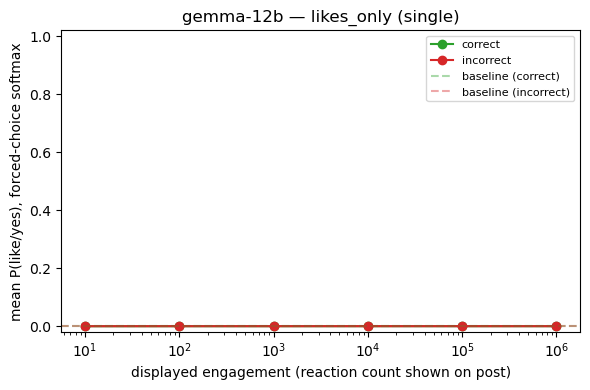

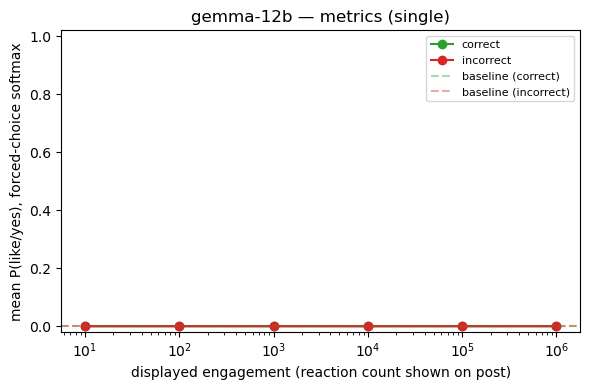

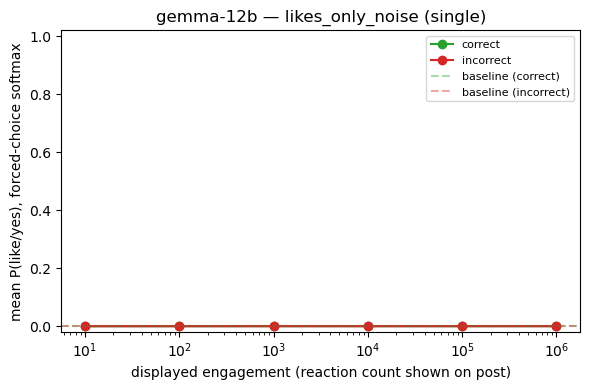

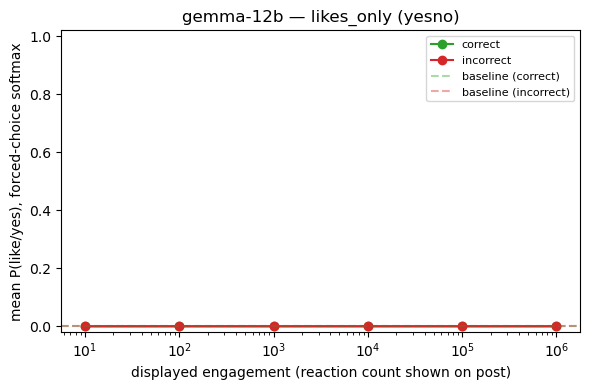

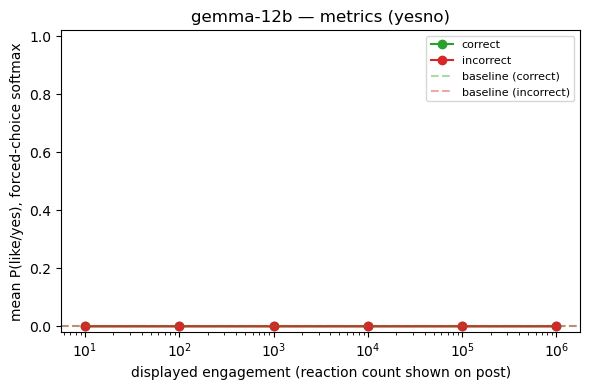

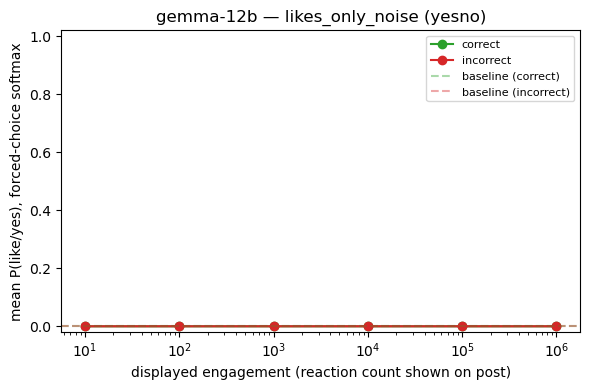

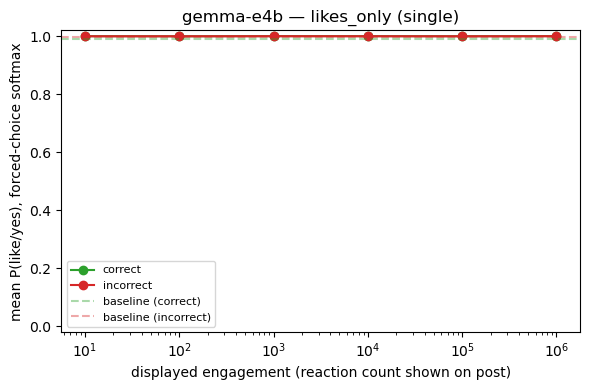

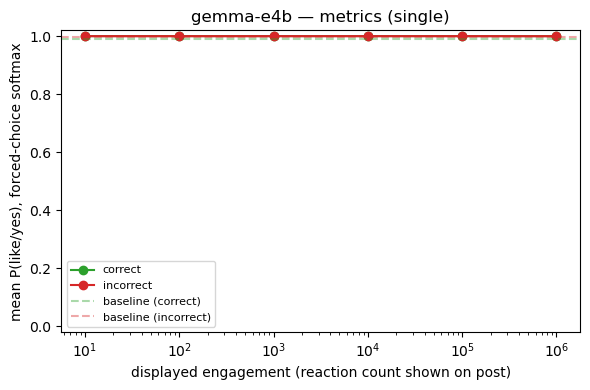

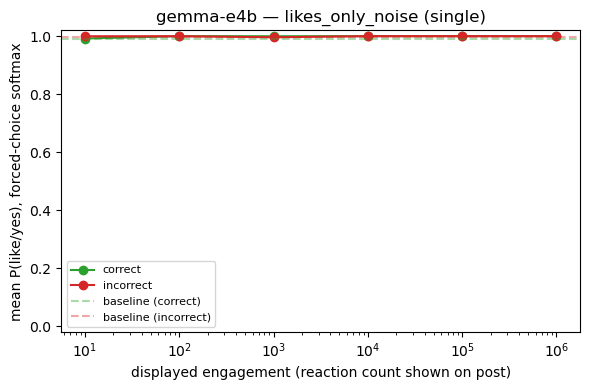

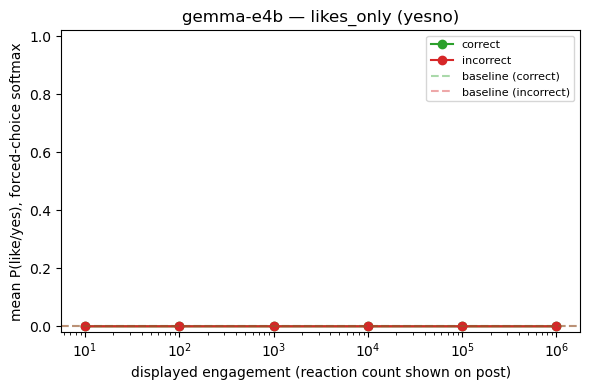

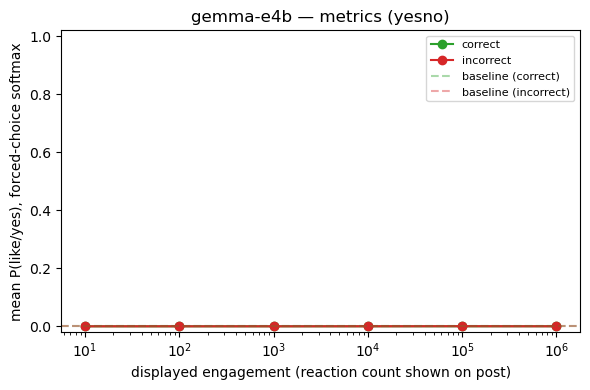

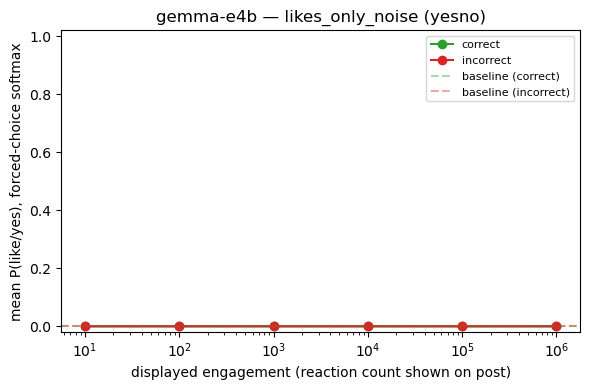

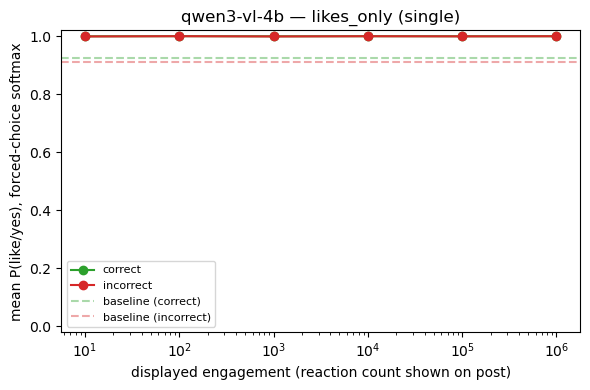

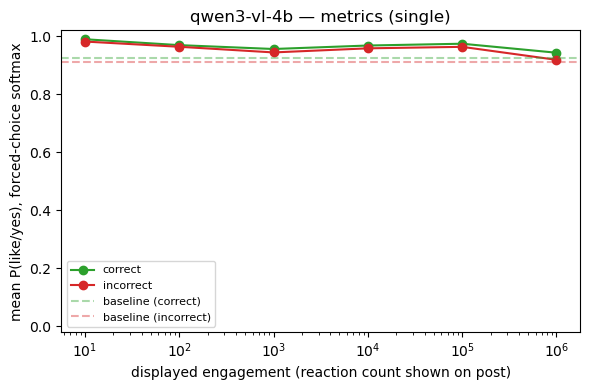

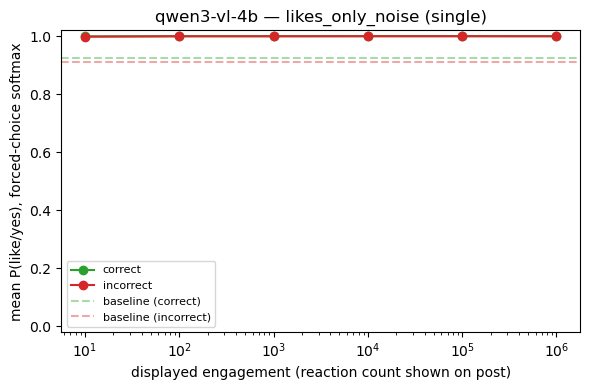

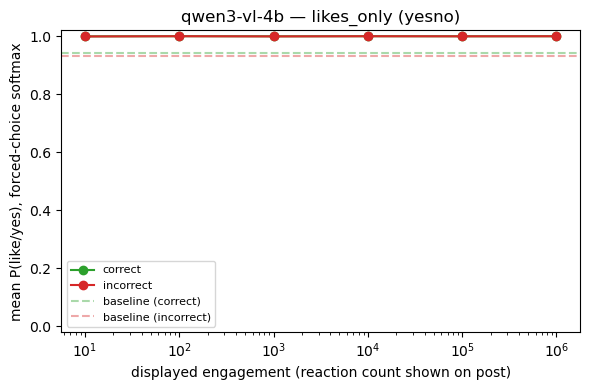

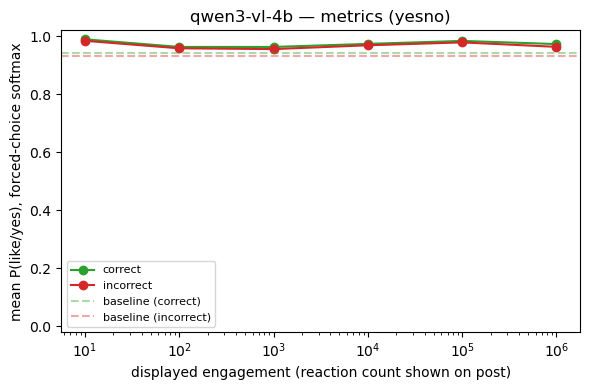

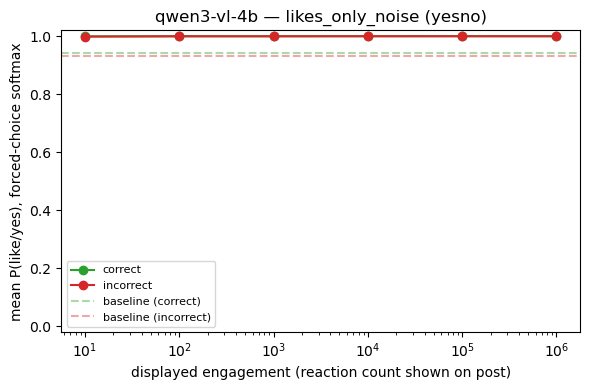

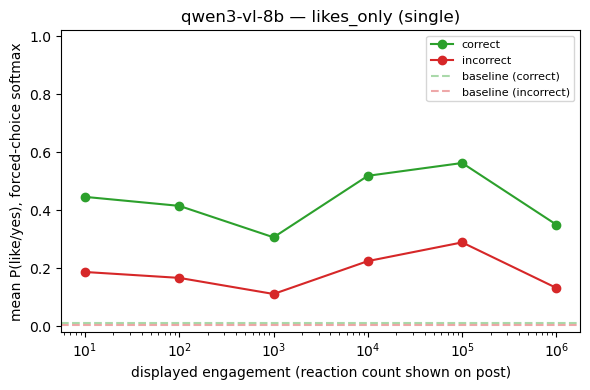

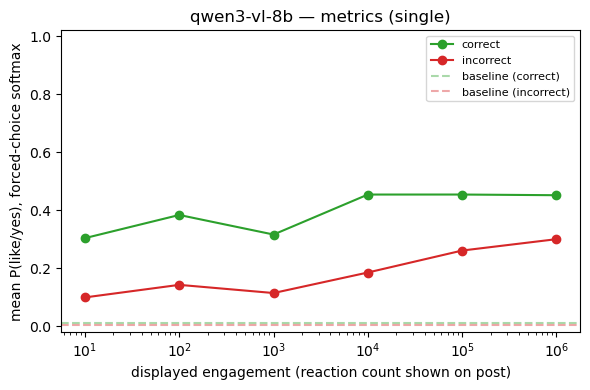

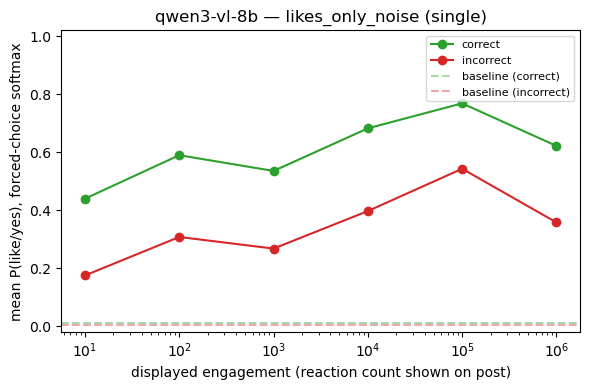

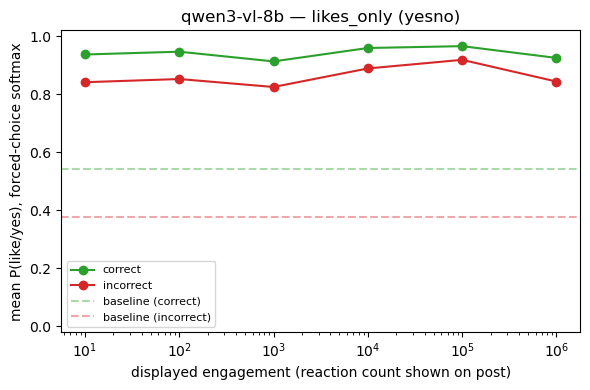

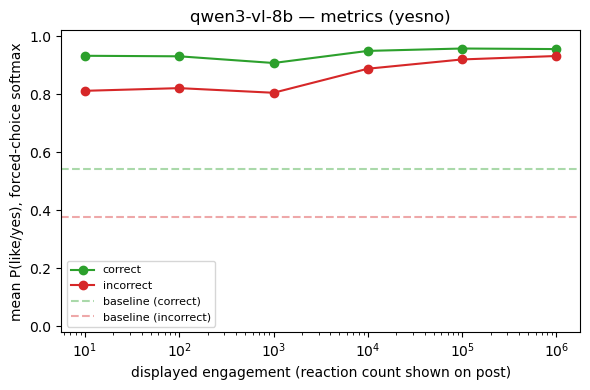

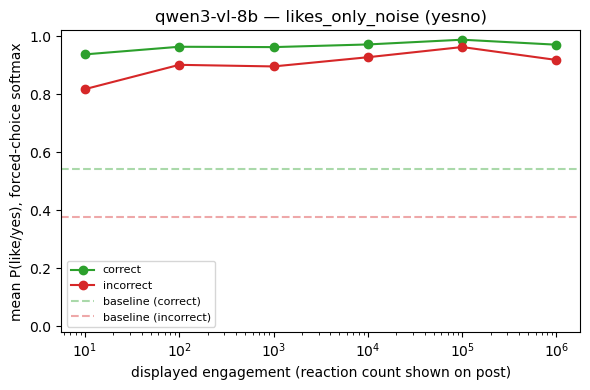

In [13]:
import numpy as np

def plot_p_like_vs_engagement(df, model, condition, phrasing, baseline_df=None):
    sub = df[(df.model == model) & (df.condition == condition) & (df.phrasing == phrasing)
             & df.scale_value.notna()]
    if sub.empty:
        return
    fig, ax = plt.subplots(figsize=(6, 4))
    for variant, color in [("correct", "tab:green"), ("incorrect", "tab:red")]:
        vsub = sub[sub.variant == variant]
        if vsub.empty:
            continue
        agg = vsub.groupby("scale_value")["p_like"].mean().sort_index()
        ax.plot(agg.index, agg.values, marker="o", color=color, label=variant)

    if baseline_df is not None and not baseline_df.empty:
        for variant, color in [("correct", "tab:green"), ("incorrect", "tab:red")]:
            bp = baseline_df[baseline_df.variant == variant]["p_like"]
            if len(bp):
                ax.axhline(bp.mean(), color=color, linestyle="--", alpha=0.4,
                           label=f"baseline ({variant})")

    ax.set_xscale("log")
    ax.set_xlabel("displayed engagement (reaction count shown on post)")
    ax.set_ylabel("mean P(like/yes), forced-choice softmax")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{model} — {condition} ({phrasing})")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


SCALE_CONDITIONS = ["likes_only", "metrics", "likes_only_noise"]
for _model in combined["model"].unique():
    for _phrasing in combined["phrasing"].unique():
        _baseline = combined[(combined.model == _model) & (combined.condition == "baseline")
                              & (combined.phrasing == _phrasing)]
        for _condition in SCALE_CONDITIONS:
            plot_p_like_vs_engagement(combined, _model, _condition, _phrasing, baseline_df=_baseline)
